In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("netflix_titles.csv")

In [2]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [3]:
df["type"].isnull().sum()
df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df["country"].isnull().sum()

np.int64(831)

In [5]:
print(df.groupby(["title", "type", "release_year", "duration", "listed_in"]).size())

title                          type     release_year  duration   listed_in                                                            
#Alive                         Movie    2020          99 min     Horror Movies, International Movies, Thrillers                           1
#AnneFrank - Parallel Stories  Movie    2019          95 min     Documentaries, International Movies                                      1
#FriendButMarried              Movie    2018          102 min    Dramas, International Movies, Romantic Movies                            1
#FriendButMarried 2            Movie    2020          104 min    Dramas, International Movies, Romantic Movies                            1
#Roxy                          Movie    2018          105 min    Comedies, Romantic Movies                                                1
                                                                                                                                         ..
忍者ハットリくん                 

In [6]:
df["director"]= df["director"].fillna("Unknown")
df["cast"]=df["cast"].fillna("Unknown")

In [7]:
df["country"] = df["country"].fillna("Unknown")

In [8]:
mcount = df[df["type"]=="Movie"]["show_id"].count()
print(mcount)

6131


In [9]:
scount = df[df["type"]=="TV Show"]["show_id"].count()
print(scount)

2676


([<matplotlib.patches.Wedge at 0x18fdca58ec0>,
 [Text(-0.6357552923508217, 0.8976721050851036, 'Movies'),
  Text(0.6357555848494867, -0.8976718979296876, 'TV Shows')],
 [Text(-0.3467756140095391, 0.48963933004642013, '69.6%'),
  Text(0.3467757735542654, -0.4896392170525568, '30.4%')])

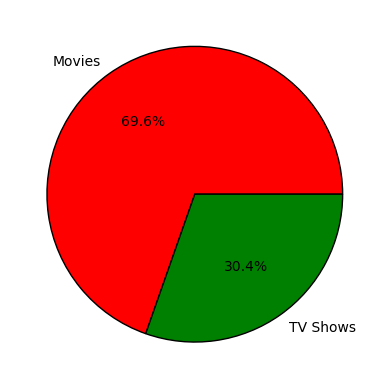

In [10]:
import matplotlib.pyplot as plt
plt.pie([mcount,scount],labels=["Movies","TV Shows"],colors=["red","green"],wedgeprops={'edgecolor':'black'},autopct='%1.1f%%')

In [11]:
years = df["release_year"].drop_duplicates().tolist()
years.sort()

In [12]:
movies= df[df["type"]=="Movie"]
shows= df[df["type"]=="TV Show"]

In [13]:
movies_per_year = movies.groupby("release_year").size()
shows_per_year = shows.groupby("release_year").size()

In [14]:
movies_per_year = movies_per_year.reindex(years,fill_value=0)
shows_per_year = shows_per_year.reindex(years,fill_value=0)

In [15]:
movies_per_year=movies_per_year.values.tolist()
shows_per_year=shows_per_year.values.tolist()

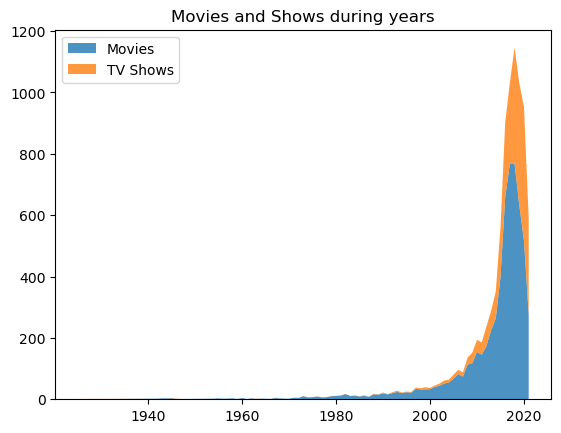

In [16]:
plt.stackplot(years,movies_per_year,shows_per_year,labels=["Movies","TV Shows"],alpha=0.8)
plt.legend(loc="upper left")
plt.title("Movies and Shows during years")
plt.show()

In [17]:
df["rating"].fillna("Unknown")

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: object

In [18]:
ratings = df["rating"].unique()
print(ratings)

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']


In [19]:
PG_13 = df[df["rating"]=="PG-13"]
TV_MA = df[df["rating"]=="TV-MA"]
TV_14 = df[df["rating"]=="TV-14"]
TV_PG = df[df["rating"]=="TV-PG"]
R = df[df["rating"]=="R"]

In [20]:
PG_13_per_year = PG_13.groupby("release_year").size().reindex(years,fill_value=0).tolist()
TV_MA_per_year = TV_MA.groupby("release_year").size().reindex(years,fill_value=0).tolist()
TV_14_per_year = TV_14.groupby("release_year").size().reindex(years,fill_value=0).tolist()
TV_PG_per_year = TV_PG.groupby("release_year").size().reindex(years,fill_value=0).tolist()
R_13_per_year = R.groupby("release_year").size().reindex(years,fill_value=0).tolist()

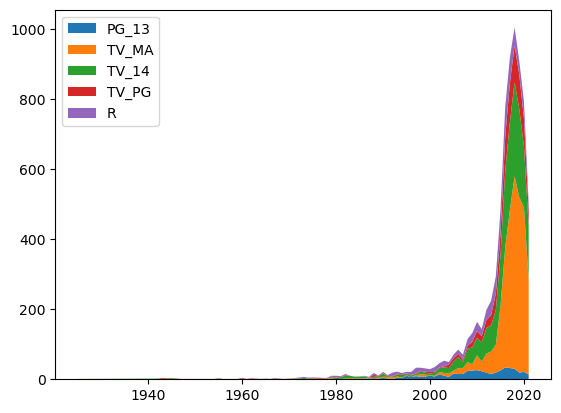

In [21]:
plt.stackplot(years,PG_13_per_year,TV_MA_per_year,TV_14_per_year,TV_PG_per_year,R_13_per_year,labels=["PG_13","TV_MA","TV_14","TV_PG","R"])
plt.legend()

In [22]:
df["duration"]=df["duration"].fillna("0")

In [23]:
avg_movie_duration = df[df["type"]=="Movie"]["duration"].str.extract(r"(\d+)")[0].dropna().astype(int).mean()

In [24]:
avg_movie_duration

np.float64(99.52846191485891)

In [25]:
avg_show_duration = df[df["type"]=="TV Show"]["duration"].str.extract(r"(\d+)")[0].dropna().astype(int).mean()

In [26]:
avg_show_duration

np.float64(1.764947683109118)

In [27]:
df_country = df.copy()
df_country["country"]=df_country["country"].str.split(", ")
df_country = df_country.explode("country")

In [28]:
df_country["country"].value_counts().head()

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64

In [29]:
US_movies = df_country[(df_country["country"]=="United States") & (df_country["type"]=="Movie")].value_counts()
US_shows = df_country[(df_country["country"]=="United States") & (df_country["type"]=="TV Show")].value_counts()

Indian_movies = df_country[(df_country["country"]=="India") & (df_country["type"]=="Movie")].value_counts()
Indian_shows = df_country[(df_country["country"]=="India") & (df_country["type"]=="TV Show")].value_counts()

Unknown_movies = df_country[(df_country["country"]=="Unknown") & (df_country["type"]=="Movie")].value_counts()
Unknown_shows = df_country[(df_country["country"]=="Unknown") & (df_country["type"]=="TV Show")].value_counts()

UK_movies = df_country[(df_country["country"]=="United Kingdom") & (df_country["type"]=="Movie")].value_counts()
UK_shows = df_country[(df_country["country"]=="United Kingdom") & (df_country["type"]=="TV Show")].value_counts()

Canada_movies = df_country[(df_country["country"]=="Canada") & (df_country["type"]=="Movie")].value_counts()
Canada_shows = df_country[(df_country["country"]=="Canada") & (df_country["type"]=="TV Show")].value_counts()



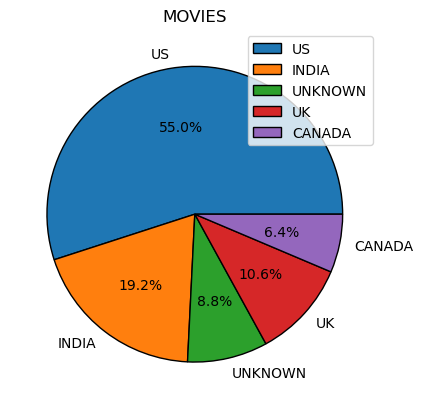

In [30]:
plt.pie([len(US_movies),len(Indian_movies),len(Unknown_movies),len(UK_movies),len(Canada_movies)],labels=["US","INDIA","UNKNOWN","UK","CANADA"],wedgeprops={'edgecolor':'black'},autopct="%1.1f%%")
plt.title("MOVIES")
plt.legend()
plt.show()

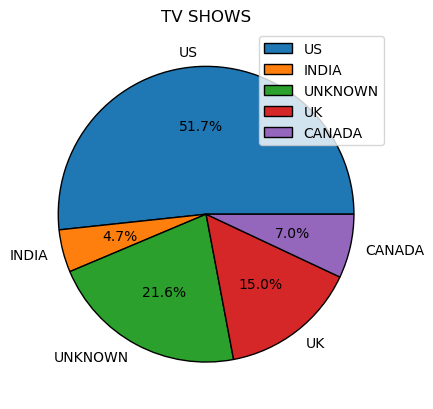

In [31]:
plt.pie([len(US_shows),len(Indian_shows),len(Unknown_shows),len(UK_shows),len(Canada_shows)],labels=["US","INDIA","UNKNOWN","UK","CANADA"],wedgeprops={'edgecolor':'black'},autopct="%1.1f%%")
plt.title("TV SHOWS")
plt.legend()
plt.show()

In [33]:
df_genre = df.copy()
df_genre["listed_in"] = df_genre["listed_in"].fillna("Unknown")
df_genre["listed_in"]=df_genre["listed_in"].str.split(", ")
df_genre = df_genre.explode("listed_in")

In [47]:
top_genres=df_genre["listed_in"].value_counts().head(8)
top_genres

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Action & Adventure         859
TV Dramas                  763
Independent Movies         756
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x18fe09f2990>,
 [Text(0.8010882770207661, 0.753828609446405, 'International Movies'),
  Text(-0.6257117877977979, 0.9047014748583555, 'Dramas'),
  Text(-1.0860552864043576, -0.17459643430823343, 'Comedies'),
  Text(-0.6041935805295731, -0.9192116825012911, 'International TV Shows'),
  Text(0.0303260652274138, -1.0995818886139508, 'Documentaries'),
  Text(0.5289614390609034, -0.964468659929714, 'Action & Adventure'),
  Text(0.8926073360730793, -0.6428469052492366, 'TV Dramas'),
  Text(1.0764245870244797, -0.22651734690565845, 'Independent Movies')],
 [Text(0.4369572420113269, 0.4111792415162208, '24.0%'),
  Text(-0.3412973387987988, 0.4934735317409211, '21.2%'),
  Text(-0.5923937925841949, -0.09523441871358186, '14.6%'),
  Text(-0.3295601348343125, -0.5013881904552496, '11.8%'),
  Text(0.01654149012404389, -0.5997719392439731, '7.6%'),
  Text(0.2885244213059473, -0.5260738145071167, '7.5%'),
  Text(0.4868767287671341, -0.35064376649958356, '6.7%'),
  Text

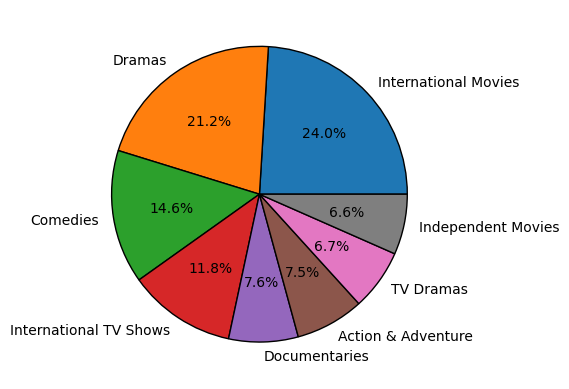

In [52]:
plt.pie(top_genres.tolist(),labels=["International Movies",
"Dramas",
"Comedies",
"International TV Shows",
"Documentaries",
"Action & Adventure",
"TV Dramas",
"Independent Movies"],autopct="%1.1f%%",wedgeprops={'edgecolor':'black'})


In [57]:
df_directors = df.copy()
df_directors["director"]=df["director"].str.split(", ")
df_directors = df_directors.explode("director")
directors = df["director"].value_counts()

In [61]:
directors.drop("Unknown").head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Youssef Chahine           12
Martin Scorsese           12
Steven Spielberg          11
Name: count, dtype: int64

In [63]:
df_actors = df.copy()
df_actors["cast"]=df_actors["cast"].str.split(", ")
df_actors= df_actors.explode("cast")
actors = df_actors["cast"].value_counts()

In [65]:
actors.head(10).drop("Unknown")

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Name: count, dtype: int64

In [79]:
df["date_added"] = df["date_added"].fillna("unknown")
df_month = df.copy()
df_month["date_added"] = df_month["date_added"].str.split(" ").str[0]
months = df_month["date_added"].value_counts()
months.head(12)

date_added
July         819
December     797
September    765
April        759
October      755
August       749
March        734
January      727
June         724
November     697
May          626
February     557
Name: count, dtype: int64

In [80]:
df_day = df.copy()
df_day["date_added"]=df_day["date_added"].str.split(", ").str[0].str.extract(r"(\d+)")[0]
days = df_day["date_added"].value_counts()

In [83]:
days.head(5)

date_added
1     2212
15     687
2      325
16     289
31     274
Name: count, dtype: int64

In [88]:
PG_13 = df[(df["rating"]=="PG-13") & (df["type"]=="Movie")]
TV_MA = df[(df["rating"]=="TV-MA") & (df["type"]=="Movie")]
TV_14 = df[(df["rating"]=="TV-14") & (df["type"]=="Movie")]
TV_PG = df[(df["rating"]=="TV-PG") & (df["type"]=="Movie")]
R = df[(df["rating"]=="R") & (df["type"]=="Movie")]
PG_13 = PG_13["duration"].str.split(" ").str[0].astype(int).mean()
TV_MA= TV_MA["duration"].str.split(" ").str[0].astype(int).mean()
TV_14= TV_14["duration"].str.split(" ").str[0].astype(int).mean()
TV_PG = TV_PG["duration"].str.split(" ").str[0].astype(int).mean()
R= R["duration"].str.split(" ").str[0].astype(int).mean()

In [90]:
print(PG_13,TV_MA,TV_14,TV_PG,R)

108.33061224489796 95.88991270611058 110.29081990189208 94.85185185185185 106.72020075282309


In [97]:
US_movies = df_country[(df_country["country"]=="United States") & (df_country["type"]=="Movie")].value_counts()
US_shows = df_country[(df_country["country"]=="United States") & (df_country["type"]=="TV Show")].value_counts()

Indian_movies = df_country[(df_country["country"]=="India") & (df_country["type"]=="Movie")].value_counts()
Indian_shows = df_country[(df_country["country"]=="India") & (df_country["type"]=="TV Show")].value_counts()

Unknown_movies = df_country[(df_country["country"]=="Unknown") & (df_country["type"]=="Movie")].value_counts()
Unknown_shows = df_country[(df_country["country"]=="Unknown") & (df_country["type"]=="TV Show")].value_counts()

UK_movies = df_country[(df_country["country"]=="United Kingdom") & (df_country["type"]=="Movie")].value_counts()
UK_shows = df_country[(df_country["country"]=="United Kingdom") & (df_country["type"]=="TV Show")].value_counts()

Canada_movies = df_country[(df_country["country"]=="Canada") & (df_country["type"]=="Movie")].value_counts()
Canada_shows = df_country[(df_country["country"]=="Canada") & (df_country["type"]=="TV Show")].value_counts()

In [107]:
countries = ["US","Indian","UK","Canada"]
movies = [len(US_movies),len(Indian_movies),len(UK_movies),len(Canada_movies)]
shows = [len(US_shows),len(Indian_shows),len(UK_shows),len(Canada_shows)]


<BarContainer object of 4 artists>

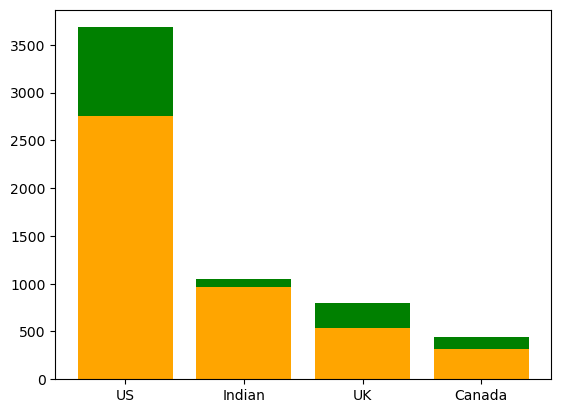

In [109]:
plt.bar(countries, movies, label="Movies", color="orange")
plt.bar(countries, shows, bottom=movies, label="TV Shows", color="green")

In [111]:
US_movies = df_country[(df_country["country"]=="United States") & (df_country["type"]=="Movie")]

Indian_movies = df_country[(df_country["country"]=="India") & (df_country["type"]=="Movie")]

UK_movies = df_country[(df_country["country"]=="United Kingdom") & (df_country["type"]=="Movie")]

Canada_movies = df_country[(df_country["country"]=="Canada") & (df_country["type"]=="Movie")]

In [115]:
print("US MOVIES:",US_movies["duration"].str.split(" ").str[0].astype(int).mean())
print("INDIAN MOVIES:",Indian_movies["duration"].str.split(" ").str[0].astype(int).mean())
print("UK MOVIES:",UK_movies["duration"].str.split(" ").str[0].astype(int).mean())
print("CANADA MOVIES:",Canada_movies["duration"].str.split(" ").str[0].astype(int).mean())

US MOVIES: 93.65757906215921
INDIAN MOVIES: 125.91268191268192
UK MOVIES: 98.8984962406015
CANADA MOVIES: 91.15047021943573


In [126]:
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
data = df[["type"]]
Type_encoded = cat_encoder.fit_transform(data)
type_df = pd.DataFrame(
    Type_encoded,
    columns = cat_encoder.get_feature_names_out(),
)

df= pd.concat([df,type_df],axis=1)

<Axes: >

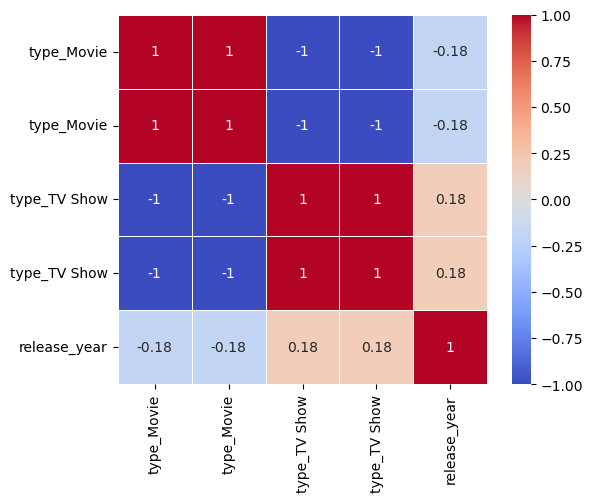

In [129]:
df_corr = df[["type_Movie","type_TV Show","release_year"]].corr()
sns.heatmap(df_corr,annot=True,cmap='coolwarm',linewidths=0.5,center=0,square=True)